# Phase 1: Data Understanding and Cleaning

## Objectives

In this phase, you will:

1. Load and understand the structure of the House Prices dataset
2. Identify and handle duplicate entries
3. Analyze data types and categorize features
4. Identify and handle missing values
5. Detect and handle outliers
6. Create a clean baseline dataset for further processing

## Instructions

Follow each task sequentially. Document your observations and decisions in markdown cells.

---
## Task 1: Import Libraries

Import the necessary libraries for data cleaning.

In [1205]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better readability
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


---
## Task 2: Load the Dataset

Load the training dataset and display basic information.

**Questions to answer:**
- How many observations (rows) are in the dataset?
- How many features (columns) are available?
- What is the target variable we want to predict?

In [1206]:
# TODO: Load the training data from 'train.csv' using pd.read_csv()
# Store it in a variable called 'df'
df = pd.read_csv('train.csv')

# TODO: Print the following information:
print("Data imported succesfuly")
print(df.shape)
print(df.shape[0])
print(df.shape[1])
# - Success message
# - Dataset shape (hint: use df.shape)
# - Number of observations (hint: df.shape[0] gives rows)
# - Number of features (hint: df.shape[1] gives columns)

Data imported succesfuly
(1460, 81)
1460
81


In [1207]:
# TODO: Display the first 5 rows of the dataset
# Use the .head() method on the dataframe
df.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [1208]:
# TODO: Display dataset information using .info() method
# This shows: data types, non-null counts, and memory usage
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Your Observations:

Write your observations here:
- Total rows: 
- Total columns: 
- Target variable: 
- Notable features: 

---
## Task 3: Check for Duplicate Rows

Identify if there are any duplicate observations in the dataset.

In [1209]:
# TODO: Check for duplicate rows in the dataset
# - Use df.duplicated() to find duplicates
# - Use .sum() to count them
# - Print message and the count
print("\nNumber of duplicate rows: ", df.duplicated().sum())

# TODO: If duplicates exist (count > 0), display them
# - Use df[df.duplicated(keep=False)] to show all duplicate rows
# - keep=False marks all duplicates as True (not just first/last occurrence)
df[df.duplicated(keep= False)]
if (df.duplicated().sum() > 0):
    df[df.duplicated(keep= True)]
else:
    print("There is not dublicated rows")


Number of duplicate rows:  0
There is not dublicated rows


**Action Required:**

If duplicates exist, decide whether to:
- Remove them (if they are exact duplicates)
- Investigate further (if they might be legitimate similar properties)

Document your decision and implement it below.

In [1210]:
# Your code here to handle duplicates if needed

---
## Task 4: Identify Feature Types

Categorize features into numerical and categorical types.

**Note:** Some numerical features might actually represent categories (e.g., MSSubClass). Use the data description file to identify these.

In [1211]:
# TODO: Create lists of categorical and numerical columns
# - Use list comprehension to filter columns by dtype
# - Categorical: df[col].dtype == 'object'
# - Numerical: df[col].dtype != 'object'
cat_col = [col for col in df.columns if df[col].dtype == 'object']
num_col = [col for col in df.columns if df[col].dtype != 'object']

# TODO: Print the following:
# - Number of categorical columns
# - Number of numerical columns
# - List of categorical column names
# - List of numerical column names
print(cat_col)
print(num_col)
print("Number of categorical columns:", len(cat_col))
print("Number of numerical columns:", len(num_col))

['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition']
['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF', 'OpenPorchSF', '

In [1212]:
# TODO: Analyze unique values in each categorical column
# - Use .nunique() to count unique values per column
# - Use .sort_values(ascending=False) to show highest cardinality first
# Hint: df[cat_col].nunique().sort_values(ascending=False)

cat_unique_counts = df[cat_col].nunique().sort_values(ascending=False)
print(cat_unique_counts)


Neighborhood     25
Exterior2nd      16
Exterior1st      15
SaleType          9
Condition1        9
Condition2        8
HouseStyle        8
RoofMatl          8
Functional        7
BsmtFinType2      6
Heating           6
RoofStyle         6
SaleCondition     6
BsmtFinType1      6
GarageType        6
Foundation        6
Electrical        5
FireplaceQu       5
HeatingQC         5
GarageQual        5
GarageCond        5
MSZoning          5
LotConfig         5
ExterCond         5
BldgType          5
BsmtExposure      4
MiscFeature       4
Fence             4
LotShape          4
LandContour       4
BsmtCond          4
KitchenQual       4
ExterQual         4
BsmtQual          4
LandSlope         3
GarageFinish      3
MasVnrType        3
PavedDrive        3
PoolQC            3
Utilities         2
CentralAir        2
Street            2
Alley             2
dtype: int64


**Question:** 

Looking at the data description file and the unique values, identify any numerical columns that should be treated as categorical. List them here and explain why.

In [1213]:
# Id
# MSSubClass
# OverallQual
# OverallCond
# MoSold
# YrSold
# BedroomAbvGr
# KitchenAbvGr
treated_as_cat = [
    'Id',
    'MSSubClass',
    'OverallQual',
    'OverallCond',
    'MoSold',
    'YrSold',
]

In [1214]:
print(df['OverallQual'].dtype)

int64


---
## Task 5: Analyze Missing Values

Identify which features have missing values and calculate the percentage of missing data.

In [1215]:
# TODO: Calculate missing values for each column
# - Use df.isnull().sum() to count missing values
# - Calculate percentage: (missing_count / total_rows) * 100
# - Round to 2 decimal places

missing_count = df.isnull().sum()
missing_percentage = round((missing_count / df.shape[0]) * 100, 2)


# TODO: Create a DataFrame with columns: 'Column', 'Missing_Count', 'Missing_Percentage'

missing_values = pd.DataFrame({
    "Column": df.columns,
    "Missing_Count": missing_count.values,
    "Missing_Percentage": missing_percentage.values
})



# TODO: Filter to show only columns with missing values (Missing_Count > 0)
# - Sort by Missing_Percentage in descending order
# - Reset the index
missing_summary = (
    missing_values[missing_values["Missing_Count"] > 0]
    .sort_values(by="Missing_Percentage", ascending=False)
    .reset_index(drop=True)
)

# TODO: Print summary
# - Number of features with missing values
# - The missing values summary DataFrame
print("Number of features with missing values:", missing_summary.shape[0])
print(missing_summary)

Number of features with missing values: 19
          Column  Missing_Count  Missing_Percentage
0         PoolQC           1453               99.52
1    MiscFeature           1406               96.30
2          Alley           1369               93.77
3          Fence           1179               80.75
4     MasVnrType            872               59.73
5    FireplaceQu            690               47.26
6    LotFrontage            259               17.74
7     GarageType             81                5.55
8    GarageYrBlt             81                5.55
9   GarageFinish             81                5.55
10    GarageQual             81                5.55
11    GarageCond             81                5.55
12  BsmtFinType2             38                2.60
13  BsmtExposure             38                2.60
14  BsmtFinType1             37                2.53
15      BsmtCond             37                2.53
16      BsmtQual             37                2.53
17    MasVnrArea     

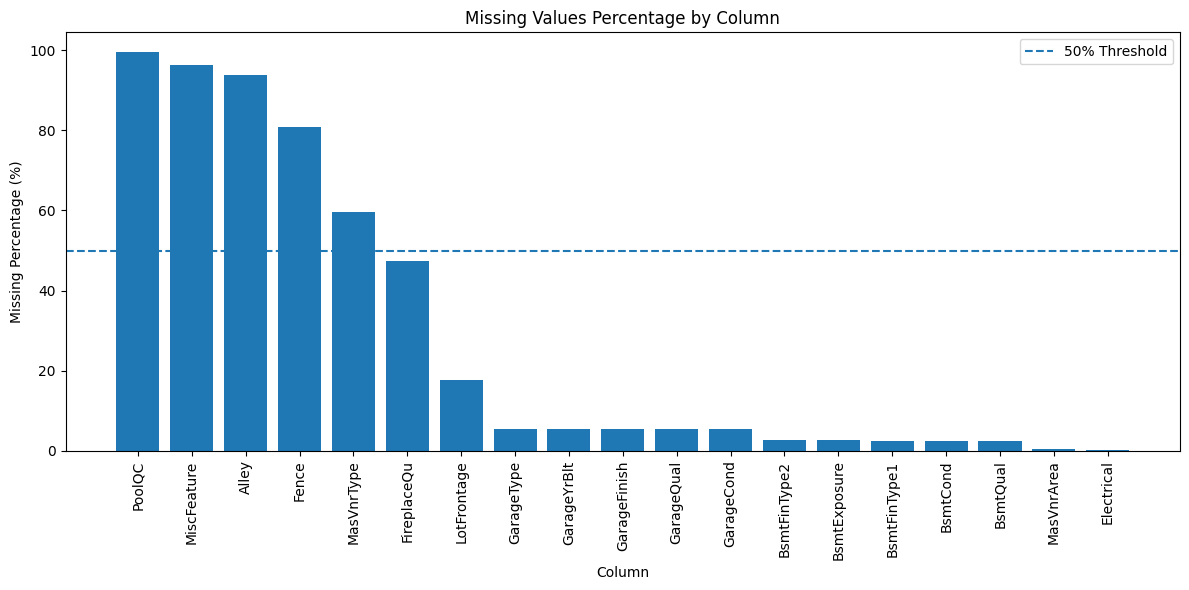

In [1216]:
# TODO: Create a bar plot to visualize missing values
# - Create figure with size (12, 6)
# - Use plt.bar() with Column names and Missing_Percentage
# - Rotate x-axis labels 90 degrees for readability
# - Add labels: xlabel, ylabel, title
# - Add horizontal line at 50% threshold (use plt.axhline)
# - Add legend and use plt.tight_layout()
# - Display with plt.show()

plt.figure(figsize=(12, 6))

plt.bar(
    missing_summary["Column"],
    missing_summary["Missing_Percentage"]
)

plt.xticks(rotation=90)

plt.xlabel("Column")
plt.ylabel("Missing Percentage (%)")
plt.title("Missing Values Percentage by Column")

plt.axhline(y=50, linestyle="--", label="50% Threshold")

plt.legend()
plt.tight_layout()
plt.show()


---
## Task 6: Handle Missing Values

Develop a strategy for handling missing values. Consider:

1. **High missing rate (>50%):** Consider dropping the feature
2. **Moderate missing rate (15-50%):** Impute or flag
3. **Low missing rate (<15%):** Impute based on feature type
4. **Missing by design:** Some features might be missing because the property doesn't have that feature (e.g., no pool, no garage). Check data_description.txt

**Strategy Guidelines:**
- For categorical: Use mode or create 'None'/'Missing' category
- For numerical: Use mean, median, or predictive imputation
- Consider the feature's importance (read data_description.txt)

### Step 6.1: Identify Features to Drop

List features with very high missing rates that provide little value.

In [ ]:
# TODO: Create a list of features to drop
# - Consider features with >50% missing values
# - Consider features with low importance (check data_description.txt)
# Example: features_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence']

# Initialize empty list

features_to_drop = [
    'Id',              # Identifier, no predictive value

    'Alley',           # >93% missing
    'PoolQC',          # ~99% missing
    'Fence',           # ~81% missing
    'MiscFeature',     # ~96% missing
    'MasVnrType',

    'Utilities',       # Almost constant . we have only NoSeWa     1
    'Street',          # Almost constant
    'RoofMatl',        # Very low variance

    'Condition2',      # Rarely different from Condition1
    'Heating',         # HeatingQC captures quality better

    'LowQualFinSF',    # Mostly zeros
    # '3SsnPorch',       # Rare feature
    # 'ScreenPorch',      # Rare feature
]


# TODO: Document reasoning for each dropped feature
# Loop through features_to_drop and print why each is being removed
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

### Step 6.2: Handle Categorical Missing Values

For categorical features with missing values, decide on imputation strategy.

In [1218]:
# TODO: Create a working copy of the dataframe
df_clean = df.copy()


# TODO: Drop selected features (if any in your features_to_drop list)
# - Use df.drop(columns=features_to_drop) if list is not empty
# - Print how many features were dropped
if features_to_drop:
    df_clean.drop(columns=features_to_drop, inplace=True)
    print(f"Dropped {len(features_to_drop)} features")

# TODO: Handle categorical missing values
# Strategy 1: Fill with 'None' for features where missing means absence
#   Example: df_clean['FeatureName'].fillna('None', inplace=True)

cat_none = [
    'BsmtQual', 'BsmtCond', 'BsmtExposure',
    'BsmtFinType1', 'BsmtFinType2',
    'FireplaceQu',
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond'
]  
for col in cat_none:
    if col in df_clean.columns:
        df_clean[col].fillna('None', inplace=True)

# Strategy 2: Fill with mode for features where missing is random
#   Example: df_clean['FeatureName'].fillna(df_clean['FeatureName'].mode()[0], inplace=True)
#
# Refer to data_description.txt to decide which strategy for each feature
cat_mode = ['Electrical']

for col in cat_mode:
    if col in df_clean.columns:
        df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)


Dropped 12 features


/var/folders/9b/_svt9z5968vbrj3rtv2c5_qc0000gp/T/ipykernel_29563/1061377319.py:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna('None', inplace=True)
/var/folders/9b/_svt9z5968vbrj3rtv2c5_qc0000gp/T/ipykernel_29563/1061377319.py:34: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always b

In [1219]:
df_clean.select_dtypes(include=['int64', 'float64']).isnull().any()


MSSubClass       False
LotFrontage       True
LotArea          False
OverallQual      False
OverallCond      False
YearBuilt        False
YearRemodAdd     False
MasVnrArea        True
BsmtFinSF1       False
BsmtFinSF2       False
BsmtUnfSF        False
TotalBsmtSF      False
1stFlrSF         False
2ndFlrSF         False
GrLivArea        False
BsmtFullBath     False
BsmtHalfBath     False
FullBath         False
HalfBath         False
BedroomAbvGr     False
KitchenAbvGr     False
TotRmsAbvGrd     False
Fireplaces       False
GarageYrBlt       True
GarageCars       False
GarageArea       False
WoodDeckSF       False
OpenPorchSF      False
EnclosedPorch    False
3SsnPorch        False
ScreenPorch      False
PoolArea         False
MiscVal          False
MoSold           False
YrSold           False
SalePrice        False
dtype: bool

### Step 6.3: Handle Numerical Missing Values

For numerical features with missing values, choose appropriate imputation.

In [1220]:
num_zero = [
    'MasVnrArea',
    'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
    'BsmtFullBath', 'BsmtHalfBath',
    'GarageCars', 'GarageArea'
]

for col in num_zero:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)




# Year-based → median
df_clean['GarageYrBlt'] = df_clean['GarageYrBlt'].fillna(
    df_clean['GarageYrBlt'].median()
)

# Location-based numeric → median
df_clean['LotFrontage'] = df_clean['LotFrontage'].fillna(
    df_clean['LotFrontage'].median()
)


# =========================
# 5. Final NA check
# =========================
df_clean.isnull().sum().sort_values(ascending=False).head()


MSSubClass     0
KitchenQual    0
GarageYrBlt    0
GarageType     0
FireplaceQu    0
dtype: int64

In [1221]:
# TODO: Verify all missing values are handled

print(df_clean.isnull().sum().sum())


0


---
## Task 7: Detect and Analyze Outliers

Use box plots and IQR method to identify outliers in key numerical features.

In [1222]:
# TODO: Select key numerical features for outlier analysis
# Focus on features related to size, area, and price
# Example list: ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'SalePrice']

# TODO: Filter to only those that exist in df_clean
# Use list comprehension: [col for col in key_numeric_features if col in df_clean.columns]
key_numeric_features = ['LotArea', 'GrLivArea', 'TotalBsmtSF', '1stFlrSF', 'SalePrice']
outlier_features = [col for col in key_numeric_features if col in df_clean.columns]

# Print selected features
print("Outlier analysis features:")
for col in outlier_features:
    print(col)

Outlier analysis features:
LotArea
GrLivArea
TotalBsmtSF
1stFlrSF
SalePrice


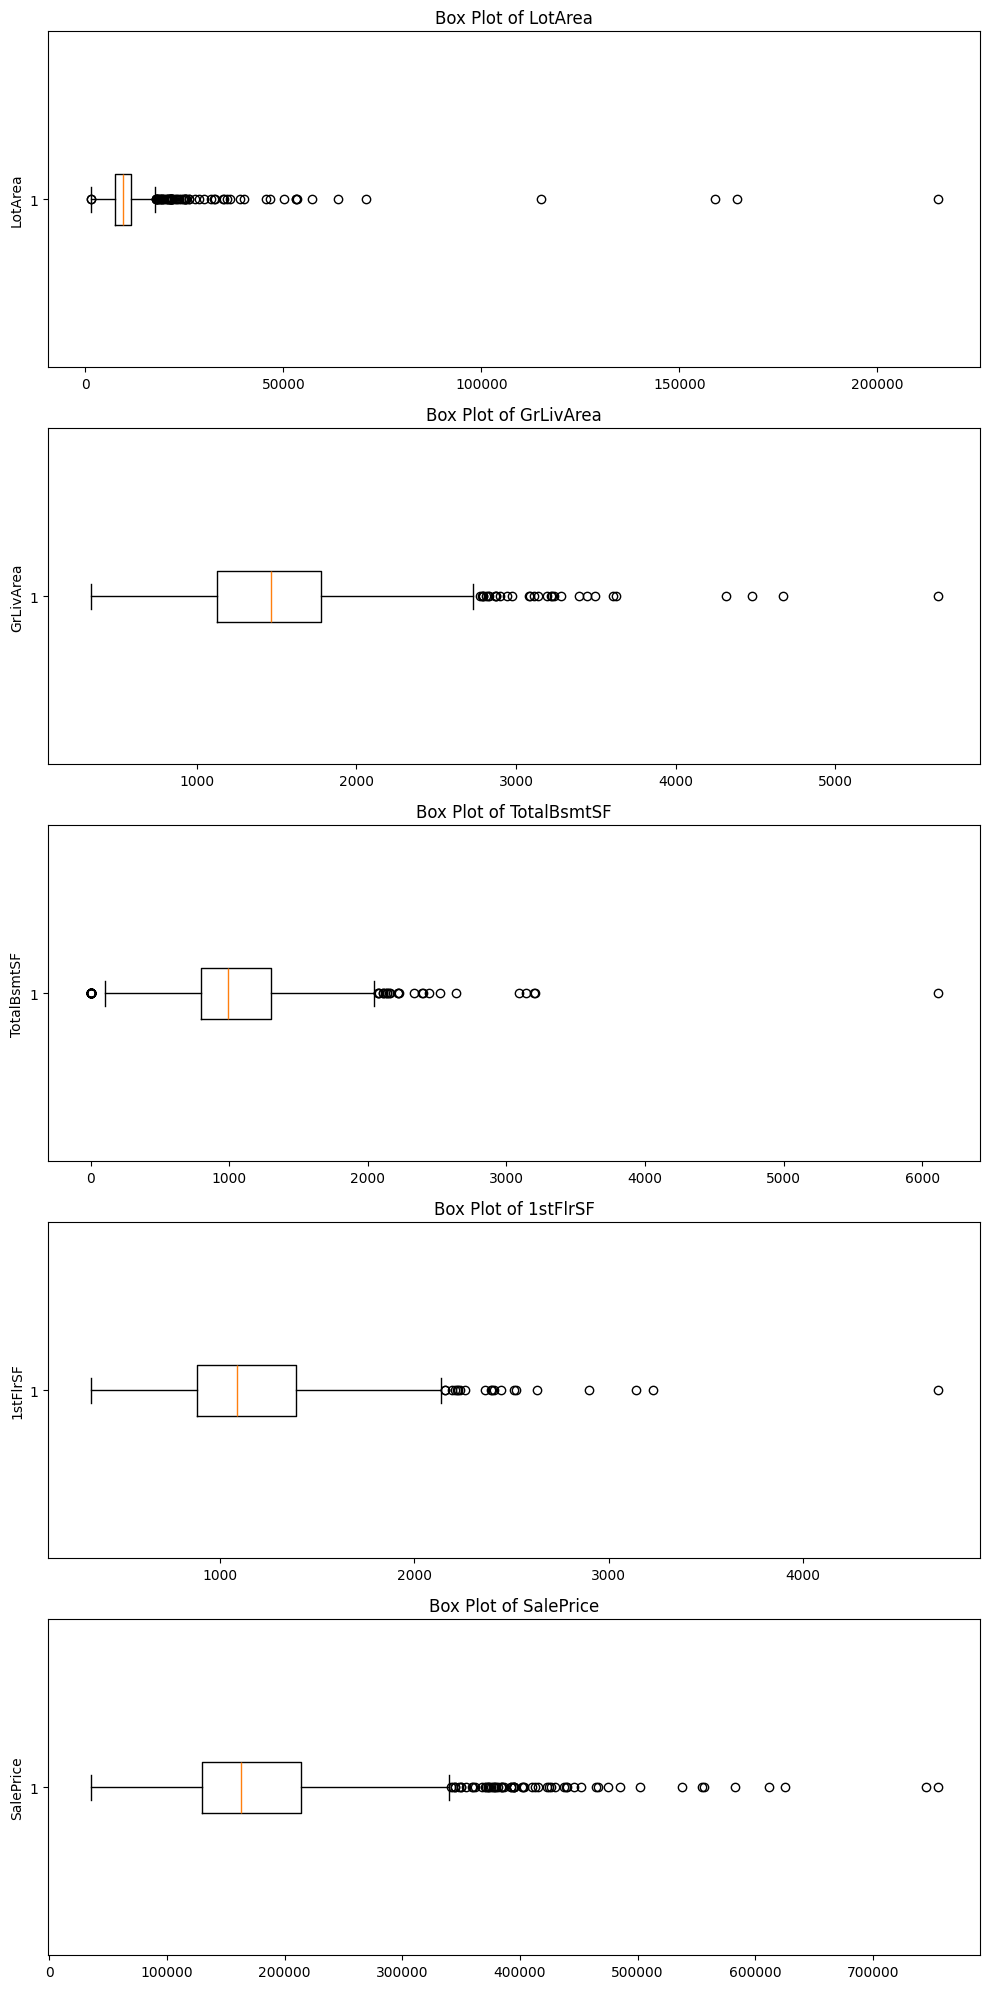

In [1223]:
# TODO: Create box plots for each key numerical feature
# - Create subplots: fig, axes = plt.subplots(n_features, 1, figsize=(10, 4*n_features))
# - Handle case when only 1 feature: convert axes to list
# - Loop through features and create horizontal box plot for each
#   - Use axes[i].boxplot(df_clean[col].dropna(), vert=False)
#   - Set ylabel and title
# - Use plt.tight_layout() and plt.show()
# Number of features
n_features = len(outlier_features)

# Create subplots
fig, axes = plt.subplots(n_features,   1, figsize=(10, 4 * n_features))

# Handle case when only one feature
if n_features == 1:
    axes = [axes]

# Create box plots
for i, col in enumerate(outlier_features):
    axes[i].boxplot(df_clean[col].dropna(), vert=False)
    axes[i].set_ylabel(col)
    axes[i].set_title(f'Box Plot of {col}')

# Adjust layout and show
plt.tight_layout()
plt.show()


### Step 7.1: Calculate Outliers Using IQR Method

For selected features, identify outliers using the IQR method.

In [1224]:
# TODO: Create a function to detect outliers using IQR method
# Function should:
# 1. Calculate Q1 (25th percentile) and Q3 (75th percentile) using np.percentile()
# 2. Calculate IQR = Q3 - Q1
# 3. Calculate bounds: lower_bound = Q1 - 1.5 * IQR, upper_bound = Q3 + 1.5 * IQR
# 4. Find outliers: values < lower_bound OR values > upper_bound
# 5. Return: outliers dataframe, lower_bound, upper_bound

def detect_outliers_iqr(df, column):
    values = df[column].dropna().values

    Q1 = np.percentile(values, 25)
    Q3 = np.percentile(values, 75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]

    return outliers, lower_bound, upper_bound



# TODO: Apply function to each key numerical feature
# - Loop through key_numeric_features
# - Print column name, bounds, and number of outliers found

for col in outlier_features:
    outliers_df, lb, ub = detect_outliers_iqr(df_clean, col)
    print(f"{col}:")
    print(f"  Lower bound = {lb:.2f}")
    print(f"  Upper bound = {ub:.2f}")
    print(f"  Number of outliers = {outliers_df.shape[0]}\n")

LotArea:
  Lower bound = 1481.50
  Upper bound = 17673.50
  Number of outliers = 69

GrLivArea:
  Lower bound = 158.62
  Upper bound = 2747.62
  Number of outliers = 31

TotalBsmtSF:
  Lower bound = 42.00
  Upper bound = 2052.00
  Number of outliers = 61

1stFlrSF:
  Lower bound = 118.12
  Upper bound = 2155.12
  Number of outliers = 20

SalePrice:
  Lower bound = 3937.50
  Upper bound = 340037.50
  Number of outliers = 61



### Step 7.2: Decision on Outliers

**Important:** Not all outliers should be removed. Consider:
- Are they data entry errors or legitimate extreme values?
- Do they represent rare but valid properties (e.g., mansions, unique homes)?
- Will removing them improve or harm model performance?

Document your decision for handling outliers.

In [1225]:
# TODO: Decide whether to remove specific outliers


df_clean = df_clean[
    (df_clean['GrLivArea'] < 4000) &
    (df_clean['LotArea'] < 35000) &
    (df_clean['TotalBsmtSF'] < 3000) &
    (df_clean['1stFlrSF'] < 2500) &
    (df_clean['SalePrice'] < 500000)
]


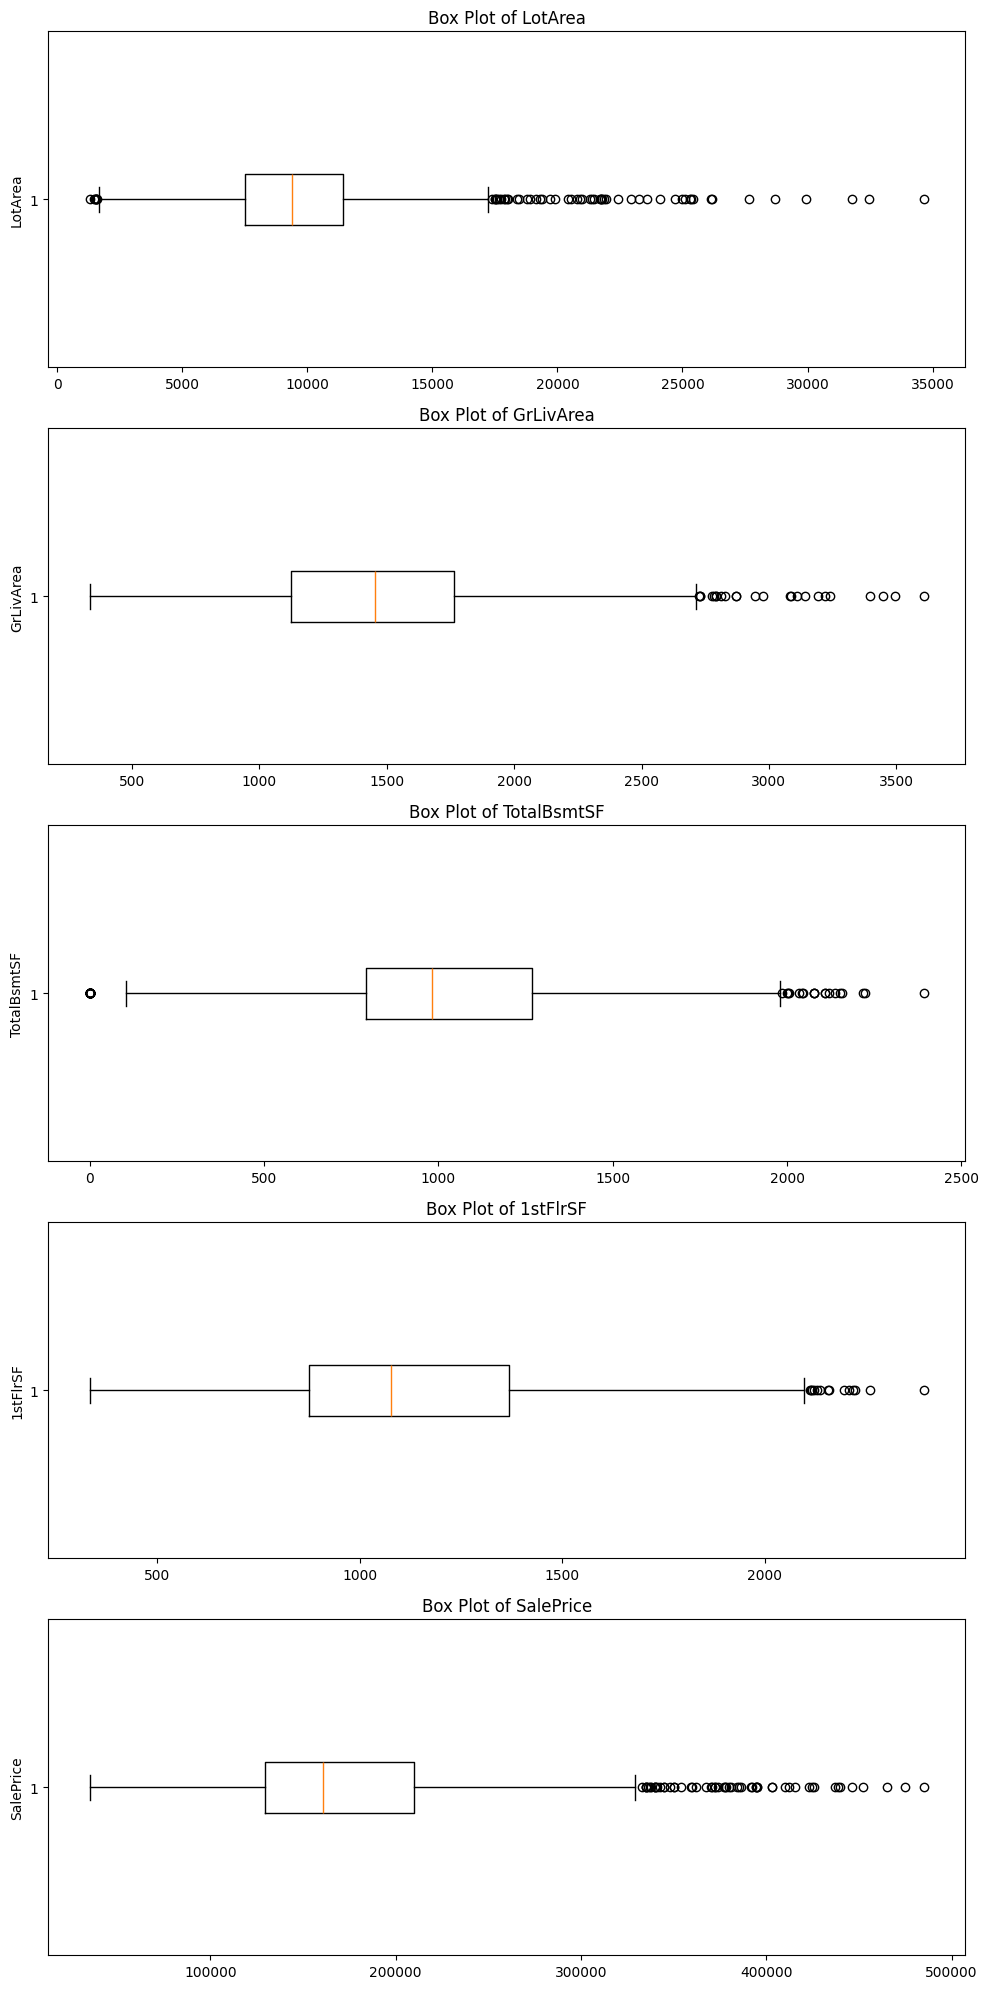

In [1226]:
# TODO: Create box plots for each key numerical feature

n_features = len(outlier_features)

# Create subplots
fig, axes = plt.subplots(n_features,   1, figsize=(10, 4 * n_features))

# Handle case when only one feature
if n_features == 1:
    axes = [axes]

# Create box plots
for i, col in enumerate(outlier_features):
    axes[i].boxplot(df_clean[col].dropna(), vert=False)
    axes[i].set_ylabel(col)
    axes[i].set_title(f'Box Plot of {col}')

# Adjust layout and show
plt.tight_layout()
plt.show()

---
## Task 8: Final Data Verification

Verify the cleaned dataset is ready for the next phase.

In [1227]:
# TODO: Print final dataset summary
# Compare original vs cleaned:
# - Original shape vs cleaned shape
# - Number of rows removed
# - Number of columns removed
# - Remaining missing values count
# - Data types value counts

# Original dataset shape
original_shape = df.shape
cleaned_shape = df_clean.shape

# Rows & columns removed
rows_removed = original_shape[0] - cleaned_shape[0]
cols_removed = original_shape[1] - cleaned_shape[1]

print("=== DATASET SUMMARY ===\n")

print(f"Original shape: {original_shape}")
print(f"Cleaned shape:  {cleaned_shape}\n")

print(f"Rows removed:    {rows_removed}")
print(f"Columns removed:{cols_removed}\n")

# Remaining missing values
print("Remaining missing values (top):")
print(df_clean.isnull().sum().sort_values(ascending=False).head(), "\n")

# Data types count
print("Data types distribution:")
print(df_clean.dtypes.value_counts())


df_clean.head()

=== DATASET SUMMARY ===

Original shape: (1460, 81)
Cleaned shape:  (1429, 69)

Rows removed:    31
Columns removed:12

Remaining missing values (top):
MSSubClass     0
KitchenQual    0
GarageYrBlt    0
GarageType     0
FireplaceQu    0
dtype: int64 

Data types distribution:
int64      33
object     33
float64     3
Name: count, dtype: int64


,MSSubClass,MSZoning,LotFrontage,LotArea,LotShape,LandContour,LotConfig,LandSlope,Neighborhood,Condition1,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,60,RL,65.0,8450,Reg,Lvl,Inside,Gtl,CollgCr,Norm,1Fam,2Story,7,5,2003,2003,Gable,VinylSd,VinylSd,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,Ex,Y,SBrkr,856,854,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,0,2,2008,WD,Normal,208500
1,20,RL,80.0,9600,Reg,Lvl,FR2,Gtl,Veenker,Feedr,1Fam,1Story,6,8,1976,1976,Gable,MetalSd,MetalSd,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,Ex,Y,SBrkr,1262,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,0,5,2007,WD,Normal,181500
2,60,RL,68.0,11250,IR1,Lvl,Inside,Gtl,CollgCr,Norm,1Fam,2Story,7,5,2001,2002,Gable,VinylSd,VinylSd,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,Ex,Y,SBrkr,920,866,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,0,9,2008,WD,Normal,223500
3,70,RL,60.0,9550,IR1,Lvl,Corner,Gtl,Crawfor,Norm,1Fam,2Story,7,5,1915,1970,Gable,Wd Sdng,Wd Shng,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,Gd,Y,SBrkr,961,756,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,60,RL,84.0,14260,IR1,Lvl,FR2,Gtl,NoRidge,Norm,1Fam,2Story,8,5,2000,2000,Gable,VinylSd,VinylSd,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,Ex,Y,SBrkr,1145,1053,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,0,12,2008,WD,Normal,250000


In [1228]:
# TODO: Save the cleaned dataset to CSV
# - Use df_clean.to_csv('train_cleaned.csv', index=False)
# - Print confirmation message
df_clean.to_csv('train_cleaned.csv', index=False)

print("Cleaned dataset saved successfully as 'train_cleaned.csv'")

Cleaned dataset saved successfully as 'train_cleaned.csv'


---
## Summary and Reflection

### What You Accomplished:

1. Loaded and understood the House Prices dataset structure
2. Identified and handled duplicate entries
3. Categorized features into numerical and categorical types
4. Analyzed and handled missing values systematically
5. Detected and addressed outliers using IQR method
6. Created a clean baseline dataset

### Key Questions for Reflection:

1. What percentage of the original data was retained after cleaning?
2. Which features had the most missing data and how did you handle them?
3. Did you identify any patterns in the missing data?
4. How did you decide which outliers to keep vs. remove?
5. What challenges did you encounter and how did you address them?

### Next Steps:

Proceed to **Phase 2: Data Preprocessing** where you will:
- Encode categorical variables
- Scale numerical features
- Handle skewness
- Prepare the data for feature engineering

In [1229]:
# Clean test data using the same rules (no target/outlier filtering)
test_raw = pd.read_csv('test.csv')
test_clean = test_raw.copy()

# Drop the same low-value columns but keep Id for submission
drop_cols = [c for c in features_to_drop if c != 'Id']
drop_cols = [c for c in drop_cols if c in test_clean.columns]
test_clean.drop(columns=drop_cols, inplace=True)

# Categorical missing handling
for col in cat_none:
    if col in test_clean.columns:
        test_clean[col].fillna('None', inplace=True)

for col in cat_mode:
    if col in test_clean.columns:
        test_clean[col].fillna(test_clean[col].mode()[0], inplace=True)

# Numeric missing handling
for col in num_zero:
    if col in test_clean.columns:
        test_clean[col] = test_clean[col].fillna(0)

if 'GarageYrBlt' in test_clean.columns:
    test_clean['GarageYrBlt'] = test_clean['GarageYrBlt'].fillna(test_clean['GarageYrBlt'].median())

if 'LotFrontage' in test_clean.columns:
    test_clean['LotFrontage'] = test_clean['LotFrontage'].fillna(test_clean['LotFrontage'].median())

print('Remaining missing values in test:', test_clean.isnull().sum().sum())
test_clean.to_csv('test_cleaned.csv', index=False)
print('Cleaned test dataset saved as test_cleaned.csv')


Remaining missing values in test: 10
Cleaned test dataset saved as test_cleaned.csv


/var/folders/9b/_svt9z5968vbrj3rtv2c5_qc0000gp/T/ipykernel_29563/3547081023.py:13: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_clean[col].fillna('None', inplace=True)
/var/folders/9b/_svt9z5968vbrj3rtv2c5_qc0000gp/T/ipykernel_29563/3547081023.py:17: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always